### Lecture Notes: Introduction to Hypothesis Testing

**Helpful Resource:**
- [Python Reference](http://data8.org/sp22/python-reference.html)

**Recommended Readings:**
- [Assessing a Model](https://www.inferentialthinking.com/chapters/11/1/Assessing_a_Model.html)
- [Decisions and P-value](https://www.inferentialthinking.com/chapters/11/3/Decisions_and_Uncertainty.html)
- [A/B Testing](https://www.inferentialthinking.com/chapters/12/1/AB_Testing.html)
- [Testing two proportions](https://www.inferentialthinking.com/chapters/12/2/Causality.html)

### Models

A model in data science, is a set of assumptions about data. Often, models include assumptions about chance processes used to generate data. Data scientists often have to decide whether or not a model is good.

### Hypotheses: Null hypothesis vs. alternative hypothesis

A hypothesis is a statement to represent a view of the world.

Null hypothesis and alternative hypothesis are two competing hypotheses.

The null hypothesis says that the data were generated at random under clearly specified assumptions about the randomness. The word “null” reinforces the idea that if the data look different from what the null hypothesis predicts, the difference is due to nothing but chance. In other word, the null hypothesis is the baseline assumption.

From a practical perspective of data science and statistics, the null hypothesis is a **model** (a set of assumptions about data) under which you can simulate data.

The alternative hypothesis says that some reason other than chance made the data differ from the predictions of the model in the null hypothesis. In other word, the alternative hypothesis is the opposite statement to the null hypothesis.

However, the alternative doesn’t say how or why the model isn’t good. It just says the model isn’t good.


In [2]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
students = Table().read_table('student_data.csv')


### Hypothesis Testing Based on Simulations

1. State the null and alternative hypothesis
2. Pick a test statistic
3. Simulate the sampling distribution of the test statistic, under the null model
4. Draw conclusion with regard to null model based on the p-value, using the distribution generated from Step 3. A significance level of 0.05 was often used to decide whether the p-value is significant enough. 


### Test Statistic

The test statistic is a single number that is computed from a dataset. The dataset can be generated from an empirical observation (real) or a theoretical random simulation (fake). The test statistic (the single number) can a mean, median, standard deviation, a proportion, a percentage, categories comparison, and simple a number out of a simple size. The test statistic can be used to guide making decision.

Test statistic is typically used to make decision on null vs alternative hypothese.

1. We have learned using `sample_proportions()` from datascience library to perform random sampling to compute a statistic.

2. `sample_proportions()` returns an array.

3. We have also learned to start with simulating one value of the statistic and then use a `for`-loop to simulate multiple values of the statistic.

#### Swain v.s. Alabama

In the [Swain v.s. Alabama (1965) case](https://inferentialthinking.com/chapters/11/1/assessing-a-model/#jury-selection), Robert Swain believes that the jury panel that convicted him under-represented the population of eligible jurors, among which 26% were black. In reality at that time, in the jury panel of 100 jurors, only 8 were black. The Supreme court opinion stated "the overall percentage disparity has been small". 

What are the null and alternative models? 

In [3]:
# simulating one value of the statistic
sample_size = 100
proportions = make_array(0.26, 0.74)
sample_proportions(sample_size, proportions)
# To get the black proportion
sample_proportions(sample_size, proportions).item(0)
# To get number of the black in the sample size
sample_proportions(sample_size, proportions).item(0) * 100

30.0

In the following code, what is the test statistic used in the simulation?

In [13]:
def sampling_distribution_black(sample_size, proportion, repeats=100000):
    results = make_array()
    proportions = make_array(proportion, 1-proportion)   
    for i in np.arange(repeats):
        results = np.append(results, sample_proportions(sample_size, proportions).item(0)*sample_size)
    return results

In [14]:
statistic_results = sampling_distribution_black(100, 0.26, 100000)
(statistic_results.max(), statistic_results.min())

(47.0, 8.0)

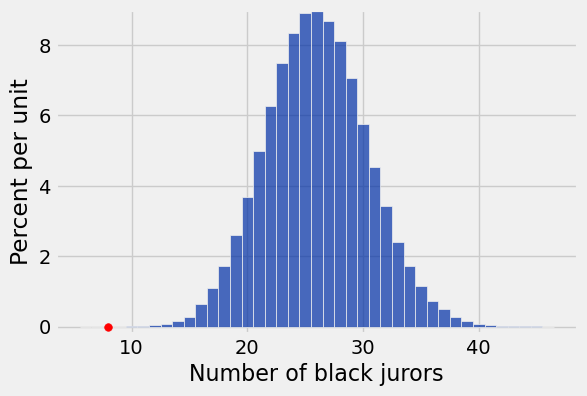

In [15]:
Table().with_column('Number of black jurors', statistic_results).hist(bins=np.arange(5.5, 47.5, 1))
#print(f"results < 10 : {np.count_nonzero(statistic_results < 10)}")

# Plotting details; ignore this code
plots.ylim(-0.002, 0.09)
plots.scatter(8, 0, color='red', s=30);

What is the overall conclusion from the hypothesis test? 

If in the county, instead of 26% of the jurors, 12% of the jurors are black. Re-run the simulation based on the new null model. What is the conclusion of this hypothesis test? 

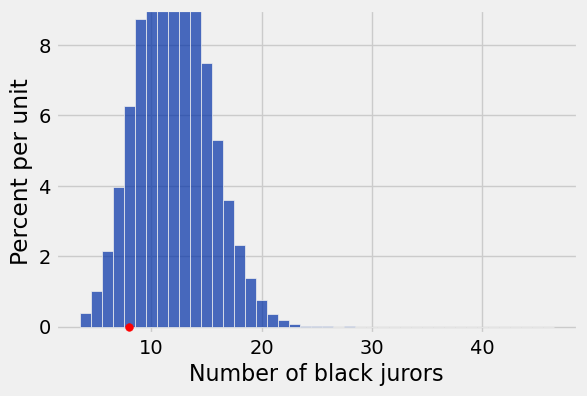

In [12]:
statistic_results = sampling_distribution_black(100, 0.12, 100000)
Table().with_column('Number of black jurors', statistic_results).hist(bins=np.arange(3.5, 47.5, 1))

#print(f"results < 10 : {np.count_nonzero(statistic_results < 10)}")

# Plotting details; ignore this code
plots.ylim(-0.002, 0.09)
plots.scatter(8, 0, color='red', s=30);

### Multiple Categories

### Total Variation Distance (TVD)

Total variation distance can be a test statistic, and TVD is particularly designed for analyzing multiple categories (3 or more). 

TVD is a distance between two distributions. It is computed by taking the absolute value of each distance, adding up all distances and dividing the total by 2.

### The loaded die

A gambler at the Graton Casino observed 120 dice rolls and noticed that the number of rolls were not perfectly even. Specifically, he counted the following frequencies for each side of the die: (18, 21, 19, 23, 24, 15). He suspects the die may be loaded. 

What are the null and alternative models? 

Based on the following code, what is value of the test statistic given the observed data? Complete the definition of the ```fair_die``` based on the null model.    

In [53]:
dice_data = make_array(18, 21, 19, 23, 24, 15)

def tvd(dist1, dist2):
    return sum(abs(dist1 - dist2))/2

fair_die = make_array(1/6, 1/6, 1/6, 1/6, 1/6, 1/6)

results = make_array()
for i in np.arange(10000):
    test_stat = tvd(sample_proportions(120, fair_die), fair_die)
    results = np.append(results, test_stat)
#Table().with_column('Test stat', results).hist()

print(tvd(dice_data/120, fair_die))


0.0666666666667


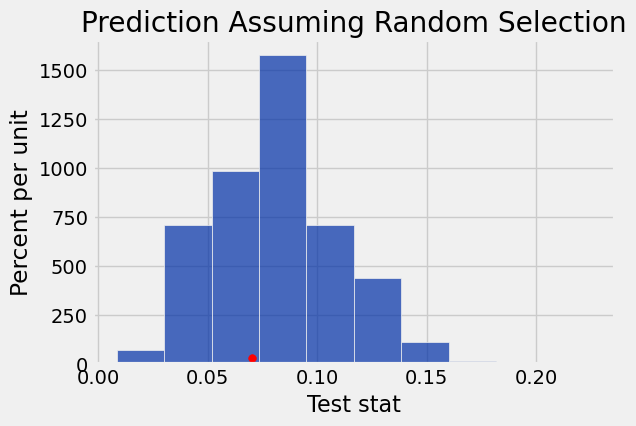

In [63]:
Table().with_column('Test stat', results).hist()
# Plotting parameters; you can ignore this code
plots.title('Prediction Assuming Random Selection')
#plots.xlim(0, 0.15)

plots.scatter(0.07, 0.3, color='red', s=30);

Imagine now instead of 120 rolls, there are 1200 dice rolls, and the frequencies were 10 times larger. Repeat the hypothesis test. Does the conclusion change? 

In [82]:
dice_data = make_array(18, 21, 19, 23, 24, 15) * 10

def tvd(dist1, dist2):
    return sum(abs(dist1 - dist2))/2

fair_die = make_array(1/6, 1/6, 1/6, 1/6, 1/6, 1/6)

results = make_array()
for i in np.arange(10000):
    test_stat = tvd(sample_proportions(1200, fair_die), fair_die)
    results = np.append(results, test_stat)
#Table().with_column('Test stat', results).hist()

print(tvd(dice_data/1200, fair_die))


0.0666666666667


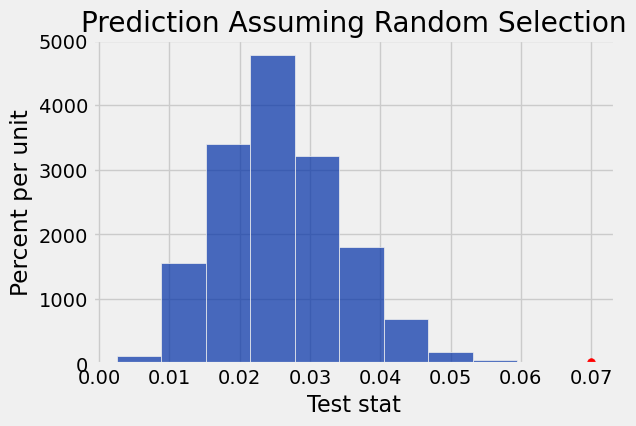

In [73]:
Table().with_column('Test stat', results).hist()
# Plotting parameters; you can ignore this code
plots.title('Prediction Assuming Random Selection')
#plots.xlim(0, 0.15)

plots.scatter(0.07, 0.3, color='red', s=30);

6.0000000000000002e-05

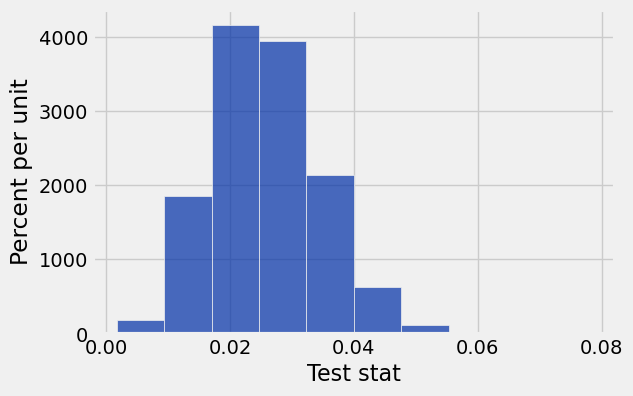

In [77]:

dice_data = dice_data = make_array(18, 21, 19, 23, 24, 15) * 10
dice_data / 1200
results = make_array()
for i in np.arange(100000):
    test_stat = tvd(sample_proportions(1200, fair_die), fair_die)
    results = np.append(results, test_stat)
Table().with_column('Test stat', results).hist()

np.count_nonzero(results >= tvd(dice_data/1200, fair_die)) / 100000